# Entrenamiento y Evaluación de la Red MS-CLSTM (Proto)

Carga la arquitectura de red y la entrena con los pipelines optimizados de TensorFlow.

In [9]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf
import tensorflow_model_optimization as tfmot
# Configurar crecimiento de memoria para evitar BFC allocator out of memory
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU Memory Growth habilitado con éxito.")
    except RuntimeError as e:
        print(f"⚠️ Error al configurar crecimiento de memoria GPU: {e}")
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Layer
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from scipy import stats

# Función puramente robusta para buscar y cargar el archivo .env
def load_env_variables():
    import os
    from pathlib import Path
    
    # 1. Buscar .env subiendo niveles desde el CWD actual
    try:
        start_dir = Path(os.getcwd())
    except:
        start_dir = Path(".")
        
    env_path = None
    for path in [start_dir] + list(start_dir.parents):
        temp_path = path / ".env"
        if temp_path.exists():
            env_path = temp_path
            break
            
    if env_path is None:
        raise FileNotFoundError("⚠️ No se pudo encontrar el archivo .env en la raíz del proyecto.")
        
    # 2. Leer e inyectar variables en os.environ
    with open(env_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, val = line.split("=", 1)
            os.environ[key.strip()] = val.strip()
            
    print(f"✅ Archivo .env cargado con éxito desde: {env_path}")

load_env_variables()

base_path = os.environ["PROCESSED_TENSOR_PROTO"]
models_dir = os.environ["MODELS_DL_PROTO"]

✅ Archivo .env cargado con éxito desde: /home/cbe/Proyectos/MyoTensor_Tesis/.env


In [10]:
@tf.keras.utils.register_keras_serializable()
class AttentionLayer(Layer, tfmot.sparsity.keras.PrunableLayer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(1,), initializer="zeros", trainable=True)
        super(AttentionLayer, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)
    def get_config(self): 
        return super(AttentionLayer, self).get_config()
    def get_prunable_weights(self):
        return [self.W]


In [11]:
print("📖 Cargando tensores...")
X_train = np.load(f'{base_path}/X_train.npy')
y_train = np.load(f'{base_path}/y_train.npy')
X_test  = np.load(f'{base_path}/X_test.npy')
y_test  = np.load(f'{base_path}/y_test.npy')

print(f"✅ X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

📖 Cargando tensores...
✅ X_train shape: (3272, 300, 1) | X_test shape: (802, 300, 1)


In [12]:
y_train_labels = np.argmax(y_train, axis=1)
classes = np.unique(y_train_labels)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_labels)
class_weight_dict = dict(zip(classes, class_weights))

batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [13]:
model_path = os.path.join(models_dir, 'myotensor_proto_net.keras')
print(f"📥 Cargando modelo desde: {model_path} ...")
base_model = tf.keras.models.load_model(model_path, custom_objects={'AttentionLayer': AttentionLayer})

import tensorflow_model_optimization as tfmot
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

epochs = 100
batch_size = 64
num_images = X_train.shape[0]
end_step = np.ceil(num_images / batch_size).astype(np.int32) * epochs

pruning_params = {
      'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.50,
                                                               final_sparsity=0.80,
                                                               begin_step=0,
                                                               end_step=end_step)
}

model_for_pruning = prune_low_magnitude(base_model, **pruning_params)

model_for_pruning.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_for_pruning.summary()

📥 Cargando modelo desde: /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/dl/myotensor_proto_net.keras ...


Model: "MS_CLSTM_TinyML"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 300, 1)]             0         []                            
                                                                                                  
 prune_low_magnitude_conv1d  (None, 300, 16)              114       ['input_1[0][0]']             
  (PruneLowMagnitude)                                                                             
                                                                                                  
 prune_low_magnitude_max_po  (None, 150, 16)              1         ['prune_low_magnitude_conv1d[0
 oling1d (PruneLowMagnitude                                         ][0]']                        
 )                                                                                  

In [14]:
trained_model_path = os.path.join(models_dir, 'myotensor_proto_net_trained.keras')
callbacks = [
    ModelCheckpoint(filepath=trained_model_path, save_best_only=True, monitor='val_accuracy', mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1),
    tfmot.sparsity.keras.UpdatePruningStep()
]

print("🚀 Iniciando entrenamiento con Weight Pruning...")
history = model_for_pruning.fit(train_dataset, validation_data=test_dataset, epochs=100, callbacks=callbacks, class_weight=class_weight_dict, verbose=1)

# Stripping
model_for_export = tfmot.sparsity.keras.strip_pruning(model_for_pruning)
model_for_export.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_for_export.save(trained_model_path)
print(f"✅ Modelo podado y exportado exitosamente a: {trained_model_path}")

🚀 Iniciando entrenamiento con Weight Pruning...
Epoch 1/100
51/52 [============================>.] - ETA: 0s - loss: 1.1850 - accuracy: 0.5009
Epoch 1: val_accuracy improved from -inf to 0.35661, saving model to /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/dl/myotensor_proto_net_trained.keras
52/52 [==============================] - 4s 25ms/step - loss: 1.1838 - accuracy: 0.5015 - val_loss: 1.3052 - val_accuracy: 0.3566 - lr: 0.0010
Epoch 2/100
51/52 [============================>.] - ETA: 0s - loss: 1.1081 - accuracy: 0.5291
Epoch 2: val_accuracy improved from 0.35661 to 0.58853, saving model to /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/dl/myotensor_proto_net_trained.keras
52/52 [==============================] - 1s 19ms/step - loss: 1.1076 - accuracy: 0.5296 - val_loss: 1.2123 - val_accuracy: 0.5885 - lr: 0.0010
Epoch 3/100
49/52 [===========================>..] - ETA: 0s - loss: 1.0776 - accuracy: 0.5332
Epoch 3: val_accuracy 

In [15]:
# Usamos model_for_export para predecir
y_pred_prob = model_for_export.predict(test_dataset)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

def apply_majority_voting(predictions, window_size=5):
    smoothed_preds = []
    for i in range(len(predictions)):
        start_idx = max(0, i - window_size + 1)
        window = predictions[start_idx : i + 1]
        mode_result = stats.mode(window, keepdims=False)[0]
        smoothed_preds.append(mode_result)
    return np.array(smoothed_preds)

y_pred_smoothed = apply_majority_voting(y_pred_classes, window_size=5)
acc_smooth = accuracy_score(y_true_classes, y_pred_smoothed)
print(f"🚀 Test Accuracy Suavizada: {acc_smooth*100:.2f}%")

13/13 [==============================] - 0s 6ms/step
🚀 Test Accuracy Suavizada: 78.05%


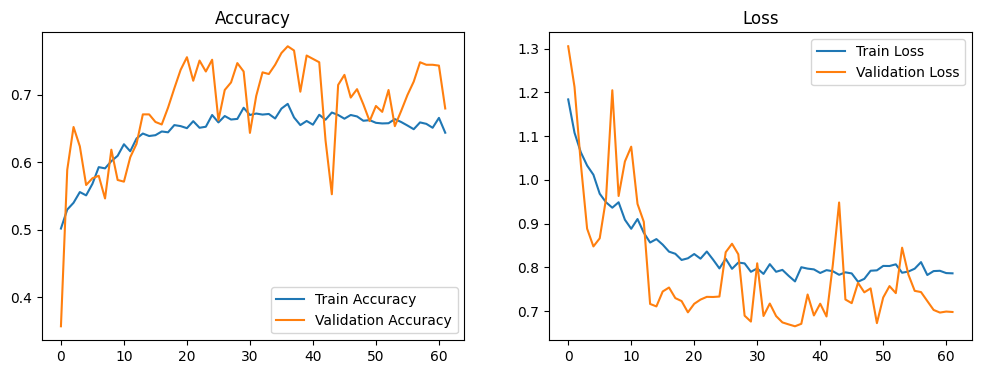


--- Evaluación Final en Test Set ---
13/13 [==============================] - 0s 7ms/step - loss: 0.6653 - accuracy: 0.7718
🏆 Test Accuracy: 77.18%


In [16]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Loss')
    plt.show()

plot_history(history)

print("\n--- Evaluación Final en Test Set ---")
loss, accuracy = model_for_export.evaluate(test_dataset)
print(f"🏆 Test Accuracy: {accuracy*100:.2f}%")


--- RESULTADOS ---
🎯 Accuracy Cruda (Ventana a Ventana): 77.18%
🚀 Accuracy Suavizada (Experiencia de Usuario): 78.05%


<Figure size 800x600 with 0 Axes>

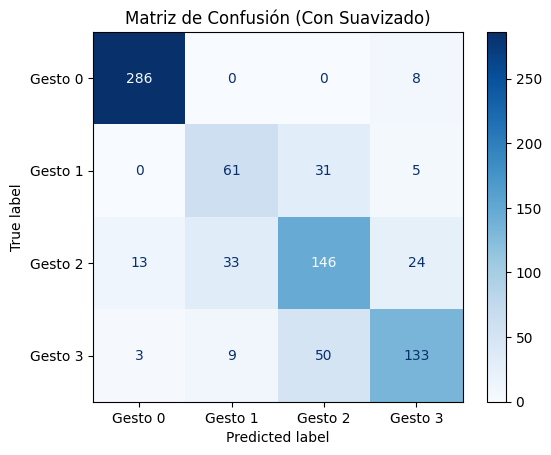


--- Reporte por Gesto ---
              precision    recall  f1-score   support

     Gesto 0       0.95      0.97      0.96       294
     Gesto 1       0.59      0.63      0.61        97
     Gesto 2       0.64      0.68      0.66       216
     Gesto 3       0.78      0.68      0.73       195

    accuracy                           0.78       802
   macro avg       0.74      0.74      0.74       802
weighted avg       0.78      0.78      0.78       802



In [17]:
acc_raw = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n--- RESULTADOS ---")
print(f"🎯 Accuracy Cruda (Ventana a Ventana): {acc_raw*100:.2f}%")
print(f"🚀 Accuracy Suavizada (Experiencia de Usuario): {acc_smooth*100:.2f}%")

# Matriz de Confusión Estética con Matplotlib
class_names = [f'Gesto {i}' for i in range(4)]
cm = confusion_matrix(y_true_classes, y_pred_smoothed)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Matriz de Confusión (Con Suavizado)')
plt.show()

# Reporte detallado por Gesto
print("\n--- Reporte por Gesto ---")
print(classification_report(y_true_classes, y_pred_smoothed, target_names=class_names))